In [2]:
!which python

/home/user/jfayzullaev/stellar-clustering/.venv-vis/bin/python


In [3]:
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [4]:
LBL_NORM = "~/stellar-clustering/network/labled-data/labels/label-normalization/labels_entities_normalized.csv"

## Transaction

silhouette, Davies–Bouldin, and Calinski–Harabasz

In [5]:
intr = pd.read_csv("transaction_kmeans_intrinsic_scores.csv").sort_values("k")

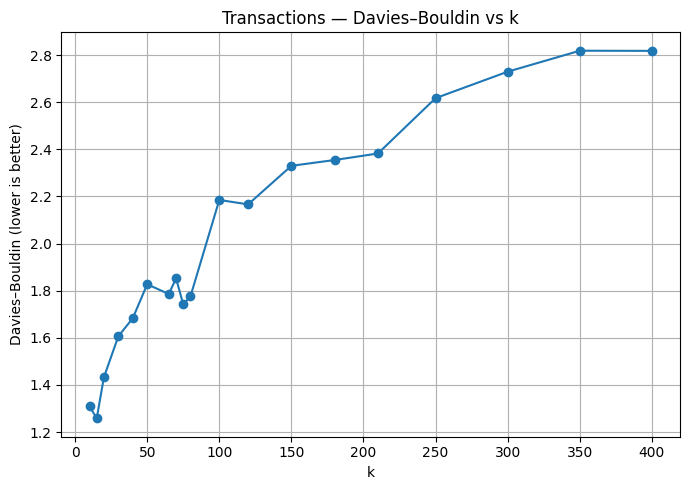

In [6]:
# Davies–Bouldin
plt.figure(figsize=(7,5))
plt.plot(intr["k"], intr["davies_bouldin"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies–Bouldin (lower is better)")
plt.title("Transactions — Davies–Bouldin vs k")
plt.grid(True, which="both", axis="both")
plt.tight_layout(); plt.show()

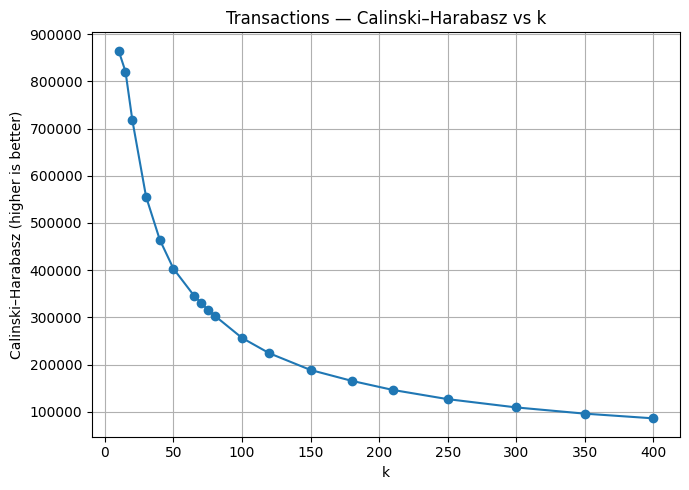

In [7]:
plt.figure(figsize=(7,5))
plt.plot(intr["k"], intr["calinski_harabasz"], marker="o")
plt.xlabel("k"); plt.ylabel("Calinski–Harabasz (higher is better)")
plt.title("Transactions — Calinski–Harabasz vs k")
plt.grid(True, which="both", axis="both")
plt.tight_layout(); plt.show()

### Extr

In [8]:
extr = pd.read_csv("transaction_kmeans_extrinsic_scores.csv").sort_values("k")

In [9]:

display(extr)

,k,NMI_vs_LBL_NORM,ARI_vs_LBL_NORM,Purity_vs_LBL_NORM
0,10,0.085179,0.029107,0.933781
1,15,0.090711,0.012911,0.933901
2,20,0.094999,0.008626,0.934021
3,30,0.097894,0.008927,0.934261
4,40,0.097551,0.008268,0.934261
5,50,0.101061,0.007674,0.934741
6,65,0.103051,0.008572,0.935101
7,70,0.098684,0.001010,0.935221
8,75,0.097911,-0.002715,0.935101
9,80,0.098838,0.003486,0.935101


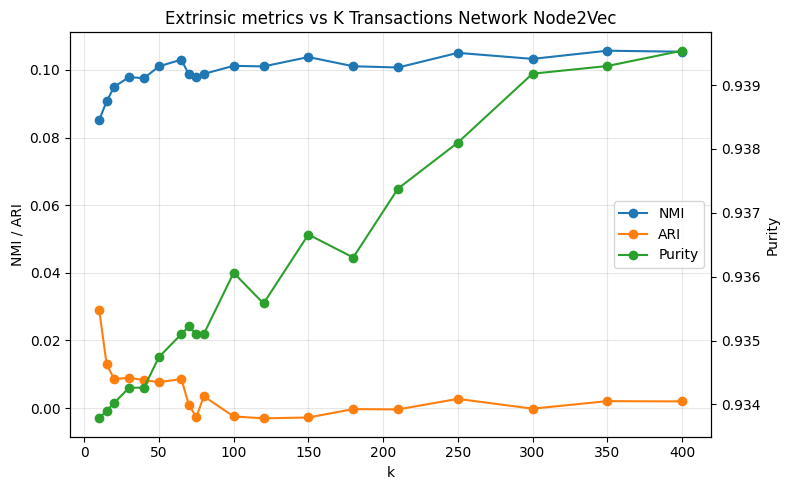

In [10]:
k   = extr["k"].astype(int)
nmi = extr["NMI_vs_LBL_NORM"]
ari = extr["ARI_vs_LBL_NORM"]
pur = extr["Purity_vs_LBL_NORM"]

fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

l1, = ax1.plot(k, nmi, marker="o", label="NMI", color="tab:blue")
l2, = ax1.plot(k, ari, marker="o", label="ARI", color="tab:orange")
l3, = ax2.plot(k, pur, marker="o", label="Purity", color="tab:green")

ax1.set_xlabel("k")
ax1.set_ylabel("NMI / ARI")
ax2.set_ylabel("Purity")

ax1.grid(True, alpha=0.3)
ax1.legend([l1, l2, l3], ["NMI", "ARI", "Purity"], loc="best")
plt.title("Extrinsic metrics vs K Transactions Network Node2Vec")
plt.tight_layout()
plt.show()

all optimal at k=10 15
